In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

# Klienti

In [2]:
sequence_client_path = r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//clients_final_df.csv"
sequence_client_df = pd.read_csv(sequence_client_path, sep=';')

In [3]:
sequence_client_df = sequence_client_df[['File', 'Listed', 'Principal']]

# pārveidojam formātu no string uz datetime, lai varētu veikt aprēķinus
sequence_client_df["Listed"] = pd.to_datetime(
    sequence_client_df["Listed"],
    format="%Y-%m-%d",
    errors="coerce"
)

# pievienojam kolonnu "payment_threshold", kas ir 2.78% no Principal vērtības
# plānotā veiksmīga parāda atguve 36 mēnešu laikā ir 2.78% no Principal vērtības, tāpēc tiek izmantota šī vērtība kā maksājumu slieksnis 100%/36
# payment_threshold = principal_prct_for_payment_threshold
sequence_client_df['principal_prct_for_payment_threshold'] = sequence_client_df['Principal'] * 0.0278

# 3 gadi no iegādes datuma (maksimālais periods), lai noteiktu periodu, kurā tiek vērtēta maksājumu aktivitāte
sequence_client_df["observation_end"] = sequence_client_df["Listed"] + pd.DateOffset(years=3)

# Maksājumi

In [4]:
sequence_transaction_path = r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//transactions_cl_df.csv"
sequence_transaction_df = pd.read_csv(sequence_transaction_path, sep=';')

In [5]:
sequence_transaction_df = sequence_transaction_df[
    ["File", "Payment date", "Payment_amount"]
].copy()

sequence_transaction_df["Payment date"] = pd.to_datetime(
    sequence_transaction_df["Payment date"],
    format="%Y-%m-%d",
    errors="coerce"
)

clients_with_payments = sequence_client_df.merge(
    sequence_transaction_df,
    on="File",
    how="left"
)


In [6]:
# Atstājam tikai maksājumus pēc Listed
clients_with_payments_after_listed = clients_with_payments[
    clients_with_payments["Payment date"].isna()
    |
    (clients_with_payments["Payment date"] >= clients_with_payments["Listed"])
].copy()

# optional: pārbaudīt, cik rindas bija dzēstas, jo maksājumu datums ir pirms Listed datuma

In [7]:
clients_with_payments_after_listed["is_significant_payment"] = (
    clients_with_payments_after_listed["Payment date"].notna()
    &
    (
        clients_with_payments_after_listed["Payment_amount"]
        >= clients_with_payments_after_listed["principal_prct_for_payment_threshold"]
    )
).astype(int)

In [8]:
# Sakārtojam rindas pirms kumulatīvās summas aprēķina
clients_with_payments_after_listed = (
    clients_with_payments_after_listed
    .sort_values(["File", "Payment date"])
    .copy()
)

# Kumulatīvā maksājumu summa katrā rindā
clients_with_payments_after_listed["cumulative_payment"] = (
    clients_with_payments_after_listed
    .groupby("File")["Payment_amount"]
    .cumsum()
)

# Vai konkrētajā rindā slieksnis jau ir sasniegts 3 gadu laikā
clients_with_payments_after_listed[
    "is_significant_payment_within_3_years"
] = (
    clients_with_payments_after_listed["Payment date"]
    <= clients_with_payments_after_listed["Listed"] + pd.DateOffset(years=3)
) & (
    clients_with_payments_after_listed["cumulative_payment"]
    >= clients_with_payments_after_listed[
        "principal_prct_for_payment_threshold"
    ]
)

In [9]:
# Katram File atlasām tikai pirmo rindu, kurā slieksnis tika sasniegts
first_significant_payment_df = (
    clients_with_payments_after_listed.loc[
        clients_with_payments_after_listed[
            "is_significant_payment_within_3_years"
        ],
        [
            "File",
            "Listed",
            "Payment date",
            "cumulative_payment"
        ]
    ]
    .sort_values(["File", "Payment date"])
    .drop_duplicates(subset="File", keep="first")
    .rename(
        columns={
            "Payment date":
                "first_significant_payment_date_within_3_years",
            "cumulative_payment":
                "first_significant_cumulative_payment_within_3_years"
        }
    )
)

In [10]:
# Saskaitīt visas vērtības kolonnā "first_significant_payment_date_within_3_years", kas ir ne vēlāk par 3 gadiem no Listed datuma:
significant_payments_count = first_significant_payment_df[
    first_significant_payment_df[
        "first_significant_payment_date_within_3_years"
    ] <= first_significant_payment_df["Listed"] + pd.DateOffset(years=3)
].shape[0]
print(f"Number of significant payments within 3 years: {significant_payments_count}")
print(f"Total number of rows in first_significant_payment_df: {first_significant_payment_df.shape[0]}")

Number of significant payments within 3 years: 6215
Total number of rows in first_significant_payment_df: 6215


Vecā loģika

In [11]:
# Atrodam pirmo maksājumu, kas ir lielāks vai vienāds ar 2.78% no Principal vērtības
# first_significant_payment_df = (
#     clients_with_payments_after_listed[
#         clients_with_payments_after_listed["is_significant_payment"] == 1
#     ]
#     .sort_values(["File", "Payment date"], na_position="last")
#     .groupby("File", as_index=False)
#     .first()
#     .rename(columns={
#         "Payment date": "first_significant_payment_date",
#         "Payment_amount": "first_significant_payment_amount"
#     })
# )

In [12]:
# Atlasām maksājumu, ar kuru pirmo reizi tika sasniegts slieksnis 3 gadu laikā
# first_significant_payment_df = (
#     clients_with_payments_after_listed.loc[
#         clients_with_payments_after_listed["Payment date"].eq(
#             clients_with_payments_after_listed[
#                 "first_significant_payment_date_within_3_years"
#             ]
#         ),
#         [
#             "File",
#             "first_significant_payment_date_within_3_years",
#             "Payment_amount"
#         ]
#     ]
#     .rename(
#         columns={
#             "Payment_amount": "first_significant_payment_amount_within_3_years"
#         }
#     )
# )

# # Pievienojam rezultātu klientu secības datiem
# first_payment_overall_df = sequence_client_df.merge(
#     first_significant_payment_df,
#     on="File",
#     how="left"
# )

In [13]:
# Ja maksājums ir vienāds vai lielāks par 2.78% no Principal, tad tas tiek uzskatīts par nozīmīgu maksājumu, un tiek piešķirta vērtība 1, pretējā gadījumā 0
# first_payment_overall_df["is_significant_payment"] = (
#     first_payment_overall_df["first_significant_payment_date"].notna()
# ).astype(int)

# first_payment_overall_df["days_to_first_significant_payment"] = (
#     first_payment_overall_df["first_significant_payment_date"] - first_payment_overall_df["Listed"]
# ).dt.days

first_significant_cumulative_payment_within_3_years - kumulatīvais maksājums 3 gadu laikā, kas pirmo reizi ir pārsniedzis 2,78% slieksni

first_significant_payment_date_within_3_years ir datums - datums, kad kumulatīvais maksājums 3 gadu laikā pirmo reizi ir pārsniedzis 2,78% slieksni


In [14]:
# Apvienojam maksājumu datus ar klientu secības datiem:
first_payment_overall_df = sequence_client_df.merge(
    first_significant_payment_df,
    on=["File", "Listed"],
    how="left",
    validate="many_to_one"
)

In [15]:
# Ja bija maksājums, tad beigu datums ir maksājuma datums. Ja nebija, tad 3 gadi no Listed
first_payment_overall_df["sequence_end_date"] = np.where(
    first_payment_overall_df["first_significant_payment_date_within_3_years"].notna(),
    first_payment_overall_df["first_significant_payment_date_within_3_years"],
    first_payment_overall_df["observation_end"]
)

first_payment_overall_df["sequence_end_date"] = pd.to_datetime(
    first_payment_overall_df["sequence_end_date"]
)

In [16]:
# Dienas līdz pirmajam nozīmīgajam maksājumam (ja tāds ir):
first_payment_overall_df["days_to_first_significant_payment"] = (
    first_payment_overall_df["first_significant_payment_date_within_3_years"] - first_payment_overall_df["Listed"]
).dt.days

In [17]:
# Piešķiram intervāla ID, pamatojoties uz dienu skaitu līdz pirmajam nozīmīgajam maksājumam
conditions = [
    first_payment_overall_df["days_to_first_significant_payment"].isna(),
    first_payment_overall_df["days_to_first_significant_payment"].between(0, 21, inclusive="both"),
    first_payment_overall_df["days_to_first_significant_payment"].between(22, 30, inclusive="both"),
    first_payment_overall_df["days_to_first_significant_payment"].between(31, 60, inclusive="both"),
    first_payment_overall_df["days_to_first_significant_payment"].between(61, 90, inclusive="both"),
    first_payment_overall_df["days_to_first_significant_payment"].between(91, 120, inclusive="both"),
    first_payment_overall_df["days_to_first_significant_payment"].between(121, 134, inclusive="both"),
    first_payment_overall_df["days_to_first_significant_payment"] >= 135
]

choices = [0, 1, 2, 3, 4, 5, 6, 7]

first_payment_overall_df["days_to_first_significant_payment_interval_id"] = np.select(
    conditions,
    choices,
    default=0
).astype(int)

<Axes: title={'center': 'Klientu skaits pēc intervāla'}, xlabel='Intervāla ID', ylabel='Klientu skaits'>

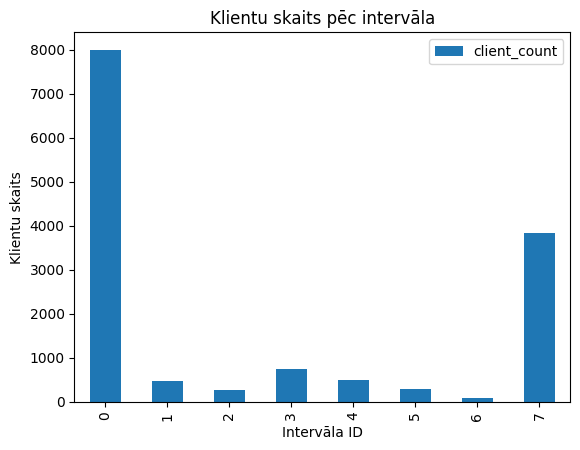

In [18]:
# Vizualizējam, cik klientu ir katrā intervālā
interval_counts = first_payment_overall_df.groupby("days_to_first_significant_payment_interval_id").size().reset_index(name="client_count")
# histogramma, kas parāda klientu skaitu katrā intervālā ar skaitlisku vērtību katrai kolonnai uz x ass, kur intervāla ID ir 0, 1, 2, 3, 4, 5, 6, 7
interval_counts.plot(x="days_to_first_significant_payment_interval_id", y="client_count", kind="bar", title="Klientu skaits pēc intervāla", xlabel="Intervāla ID", ylabel="Klientu skaits")

In [19]:
sequence_events_path = r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//final_events_clean_df.csv"
sequence_events_df = pd.read_csv(sequence_events_path, sep=';')
sequence_events_df = sequence_events_df[['File', 'Type', 'Contact_date']]

In [20]:
# Inner join, jo mūs interesē tikai aktivitāšu secības (ir lietas bez aktivitātēm - nepamatoti cedētas)
clients_with_events = first_payment_overall_df.merge(
    sequence_events_df,
    on="File",
    how="inner"
)

In [21]:
events_before_payment = clients_with_events[
    (clients_with_events["Contact_date"] >= clients_with_events["Listed"]) &
    (clients_with_events["Contact_date"] < clients_with_events["sequence_end_date"])
].copy()

In [22]:
action_sequence_df = (
    events_before_payment
    .sort_values(["File", "Contact_date"])
    .groupby("File")["Type"]
    .apply(lambda x: " → ".join(x))
    .reset_index()
    .rename(columns={"Type": "action_sequence"})
)

Šī pieeja izveido 12977 unikālās kombinācijas. Līdz ar to tika nolemts tās sagrupēt pēc skaita.

In [23]:
# Katrai lietai (File) saskaitam kopējo aktivitāšu skaitu pa tipiem (Type):
action_counts_df = (
    events_before_payment
    .groupby(["File", "Type"])
    .size()
    .reset_index(name="action_count")
)

In [24]:
# Izveidojam kolonnas katram Type un pievienojam skaitu no action_count:
action_counts_pivot_df = action_counts_df.pivot_table(
    index="File",   
    columns="Type",
    values="action_count",
    fill_value=0
).reset_index()

# Skaita kolonnās jābūt integer tipam, nevis float, jo skaits nevar būt decimāldaļskaitlis:
action_counts_pivot_df = action_counts_pivot_df.astype({col: 'int' for col in action_counts_pivot_df.columns if col != 'File'})


In [25]:
# Apvienojam maksājumus ar sagrupētām aktivitātēm
sequence_result_df = first_payment_overall_df.merge(
    action_counts_pivot_df,
    on="File",
    how="left"
)

# Piešķiram int formātu kolonnām, kas satur skaitu
count_columns = ['CALL OR MANUAL EMAIL', 'DIALER', 'EMAIL', 'POST MAIL', 'SMS']
sequence_result_df[count_columns] = sequence_result_df[count_columns].fillna(0).astype(int)


In [26]:
# Izveidojam secības, izmantojot aktivitāšu skaitu un secību, pēc parauga: CALL OR MANUAL EMAIL: 6 → DIALER: 3 → EMAIL: 2 → POST MAIL: 1 → SMS: 0
sequence_result_df["action_sequence"] = (
    sequence_result_df[count_columns]
    .apply(lambda x: " → ".join([f"{col}: {val}" for col, val in zip(count_columns, x) if val > 0]), axis=1)
)


In [27]:
# Noteikt, kura ir visbiežāk sastopama secība katrā days_to_first_significant_payment_interval_id: 
# sagrupēt pēc days_to_first_significant_payment_interval_id un action_sequence, saskaitīt katras secības skaitu, un noteikt visbiežāk sastopamo secību katrā intervālā
most_common_sequences = (
    sequence_result_df
    .groupby(["days_to_first_significant_payment_interval_id", "action_sequence"])
    .size()
    .reset_index(name="sequence_count")
    .sort_values(["days_to_first_significant_payment_interval_id", "sequence_count"], ascending=[True, False])
    .groupby("days_to_first_significant_payment_interval_id")
    .first()
    .reset_index()
)

In [28]:
# Statistika pa intervāliem days_to_first_significant_payment_interval_id: 
sequence_summary = (
    sequence_result_df
    .groupby("days_to_first_significant_payment_interval_id")
    .agg(
        cases=("File", "count"),
        avg_first_cumulative_payment = ("first_significant_cumulative_payment_within_3_years", "mean"),
        avg_days_to_first_significant_payment=("days_to_first_significant_payment", "mean")
    )
    .reset_index()
)

# Kolonnās avg_first_cumulative_payment un avg_days_to_first_significant_payment aizpildīt NaN vērtības ar 0, jo, ja nav maksājuma, tad vidējā vērtība ir 0; un noapaļot līdz 2 cipariem aiz komata
sequence_summary["avg_first_cumulative_payment"] = sequence_summary["avg_first_cumulative_payment"].fillna(0).round(2)
sequence_summary["avg_days_to_first_significant_payment"] = sequence_summary["avg_days_to_first_significant_payment"].fillna(0).round(2)


In [29]:
# Pievienot pie sequence_summary arī visbiežāk sastopamo secību katrā intervālā
sequence_summary = sequence_summary.merge(
    most_common_sequences[["days_to_first_significant_payment_interval_id", "action_sequence", "sequence_count"]],
    on="days_to_first_significant_payment_interval_id",
    how="left"
)

In [30]:
# Saglabājam rezultātus CSV failā
sequence_summary.to_csv(r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//sequence_summary.csv", sep=';', index=False, encoding='utf-8-sig')

In [31]:
# CALL OR MANUAL EMAIL: 1–9 un 10+
sequence_result_df["CALL OR MANUAL EMAIL group"] = pd.cut(
    sequence_result_df["CALL OR MANUAL EMAIL"],
    bins=[0, 9, np.inf],
    labels=["<10", "10+"]
)

# DIALER: 1–9 un 10+
sequence_result_df["DIALER group"] = pd.cut(
    sequence_result_df["DIALER"],
    bins=[0, 9, np.inf],
    labels=["<10", "10+"]
)

# EMAIL: 1–9, 10–99 un 100+
sequence_result_df["EMAIL group"] = pd.cut(
    sequence_result_df["EMAIL"],
    bins=[0, 9, 99, np.inf],
    labels=["<10", "10-99", "100+"]
)

# POST MAIL: 1–4 un 5+
sequence_result_df["POST MAIL group"] = pd.cut(
    sequence_result_df["POST MAIL"],
    bins=[0, 4, np.inf],
    labels=["<5", "5+"]
)

# SMS: 1–4 un 5+
sequence_result_df["SMS group"] = pd.cut(
    sequence_result_df["SMS"],
    bins=[0, 4, np.inf],
    labels=["<5", "5+"]
)

In [32]:
grouped_sequence_result_df = sequence_result_df[['File', 'Principal', 'first_significant_cumulative_payment_within_3_years', 'days_to_first_significant_payment',
                                                 'days_to_first_significant_payment_interval_id', 'CALL OR MANUAL EMAIL group',
                                                 'DIALER group', 'EMAIL group', 'POST MAIL group', 'SMS group']]

In [33]:
# Izveidojam secības, izmantojot aktivitāšu skaitu un secību
grouped_columns = ['CALL OR MANUAL EMAIL group', 'DIALER group', 'EMAIL group', 'POST MAIL group', 'SMS group']

sequence_result_df["action_pattern"] = sequence_result_df[grouped_columns].apply(
    lambda row: " → ".join(
        f"{column.replace(' group', '')}: {value}"
        for column, value in row.items()
        if pd.notna(value)
    ),
    axis=1
)

sequence_result_df["action_pattern"] = (
    sequence_result_df["action_pattern"]
    .replace("", "NO_ACTION")
)

In [34]:
# Sagrupējam pēc action_pattern un aprēķinām statistiku
action_summary = (
    sequence_result_df
    .groupby("action_pattern")
    .agg(
        cases=("File", "count"),
        avg_first_cumulative_payment = ("first_significant_cumulative_payment_within_3_years", "mean"),
        avg_days_to_first_significant_payment=("days_to_first_significant_payment", "mean")
    )
    .reset_index()
)

# Noapaļojam līdz 2 cipariem aiz komata kolonnas avg_first_cumulative_payment un avg_days_to_first_significant_payment
action_summary[
    [
        "avg_first_cumulative_payment",
        "avg_days_to_first_significant_payment"
    ]
] = action_summary[
    [
        "avg_first_cumulative_payment",
        "avg_days_to_first_significant_payment"
    ]
].round(2)

# Sakārtojam pēc gadījumu skaita
action_summary = action_summary.sort_values(
    "cases",
    ascending=False
).reset_index(drop=True)

In [35]:
# Sagrupējam pēc intervāla, lai iegūtu statistiku katrā intervālā - visbiežāk sastopamās secības, vidējais pirmais kumulatīvais maksājums un vidējais dienu skaits līdz pirmajam nozīmīgajam maksājumam
interval_action_summary = (
    sequence_result_df
    .groupby("days_to_first_significant_payment_interval_id")
    .agg(
        cases=("File", "count"),
        action_pattern=("action_pattern", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        avg_first_cumulative_payment = ("first_significant_cumulative_payment_within_3_years", "mean"),
        avg_days_to_first_significant_payment=("days_to_first_significant_payment", "mean")
    )
    .reset_index()
)

# Noapaļojam līdz 2 cipariem aiz komata kolonnas avg_first_cumulative_payment un avg_days_to_first_significant_payment
interval_action_summary[
    [
        "avg_first_cumulative_payment",
        "avg_days_to_first_significant_payment"
    ]
] = interval_action_summary[
    [
        "avg_first_cumulative_payment",
        "avg_days_to_first_significant_payment"
    ]
].round(2)

# Sakārtojam pēc gadījumu skaita
interval_action_summary = interval_action_summary.sort_values(
    ["days_to_first_significant_payment_interval_id", "cases"],
    ascending=[True, False]
).reset_index(drop=True)

In [36]:
# Saglabājam rezultātus CSV failā
action_summary.to_csv(r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//action_summary.csv", sep=';', index=False, encoding='utf-8-sig')
interval_action_summary.to_csv(r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//interval_action_summary.csv", sep=';', index=False, encoding='utf-8-sig')
sequence_result_df.to_csv(r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//sequence_result_df.csv", sep=';', index=False, encoding='utf-8-sig')

In [ ]:
activity_columns = [
    'CALL OR MANUAL EMAIL',
    'DIALER',
    'EMAIL',
    'POST MAIL',
    'SMS'
]

avg_summary = (
    sequence_result_df
    .groupby(
        'days_to_first_significant_payment_interval_id',
        observed=True
    )[activity_columns]
    .mean()
    .round(2)
    .reset_index()
)

avg_summary


,days_to_first_significant_payment_interval_id,CALL OR MANUAL EMAIL,DIALER,EMAIL,POST MAIL,SMS
0,0,38.71,23.77,59.50,7.98,14.35
1,1,1.51,0.00,1.07,0.96,0.41
2,2,2.44,0.00,1.39,1.11,0.88
3,3,2.99,0.01,2.24,1.52,1.19
4,4,4.26,0.03,3.63,1.83,1.96
5,5,6.08,0.13,4.94,2.14,3.00
6,6,7.02,0.20,5.43,2.55,3.24
7,7,30.10,12.46,30.92,5.30,11.65


In [38]:
median_summary = (
    sequence_result_df
    .groupby(
        'days_to_first_significant_payment_interval_id',
        observed=True
    )[activity_columns]
    .median()
    .round(2)
    .reset_index()
)

median_summary

,days_to_first_significant_payment_interval_id,CALL OR MANUAL EMAIL,DIALER,EMAIL,POST MAIL,SMS
0,0,30.0,4.0,72.0,9.0,10.0
1,1,2.0,0.0,1.0,1.0,0.0
2,2,2.0,0.0,1.0,1.0,1.0
3,3,3.0,0.0,2.0,1.0,1.0
4,4,4.0,0.0,3.0,2.0,1.0
5,5,5.0,0.0,3.5,2.0,2.0
6,6,6.0,0.0,5.0,2.0,2.0
7,7,22.0,2.0,23.0,5.0,9.0


In [39]:
mode_summary = (
    sequence_result_df
    .groupby(
        'days_to_first_significant_payment_interval_id',
        observed=True
    )[activity_columns]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
)

mode_summary

,days_to_first_significant_payment_interval_id,CALL OR MANUAL EMAIL,DIALER,EMAIL,POST MAIL,SMS
0,0,7,0,0,9,0
1,1,2,0,0,1,0
2,2,2,0,0,1,0
3,3,3,0,0,1,0
4,4,3,0,0,2,0
5,5,4,0,0,2,0
6,6,5,0,0,2,0
7,7,8,0,0,3,0


In [40]:
mode_summary_all = (
    sequence_result_df
    .groupby(
        'days_to_first_significant_payment_interval_id',
        observed=True
    )[activity_columns]
    .agg(lambda x: x.mode().tolist())
    .reset_index()
)

mode_summary_all

,days_to_first_significant_payment_interval_id,CALL OR MANUAL EMAIL,DIALER,EMAIL,POST MAIL,SMS
0,0,[7],[0],[0],[9],[0]
1,1,[2],[0],[0],[1],[0]
2,2,[2],[0],[0],[1],[0]
3,3,[3],[0],[0],[1],[0]
4,4,[3],[0],[0],[2],[0]
5,5,"[4, 5]",[0],[0],[2],"[0, 2]"
6,6,"[5, 6]",[0],[0],[2],[0]
7,7,[8],[0],[0],[3],[0]


In [41]:
avg_summary.to_csv(r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//Aktivitāšu statistika//avg_summary.csv", sep=';', index=False, encoding='utf-8-sig')
median_summary.to_csv(r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//Aktivitāšu statistika//median_summary.csv", sep=';', index=False, encoding='utf-8-sig')
mode_summary.to_csv(r"G:\GSCLV-FIN\Current month BI Reports\Client profile//2026//Valuation data//Aktivitāšu statistika//mode_summary.csv", sep=';', index=False, encoding='utf-8-sig')